# Лабораторная работа 6. Модели линейной регрессии

## Задание 4. Поиск минимумов с помощью градиентного спуска


**Задача** - найти минимумы функции f(x, y) с помощью градиентного спуска. 

In [16]:
import numpy as np
from numpy import pi, sin, exp, log
import plotly.graph_objects as go
import random

In [17]:
def f(x, y):
    return 10*((x)**5 + pi)*sin(log(((y)**4)+1))/exp(0.8*x**2) + x*5 + 1*(1 - x)**2 - y*2

In [18]:
def gradient_f(x, y):
    """Вычисление градиента функции f(x,y) с помощью численного дифференцирования"""
    h = 1e-7
    df_dx = (f(x + h, y) - f(x, y)) / h
    df_dy = (f(x, y + h) - f(x, y)) / h
    return np.array([df_dx, df_dy])

In [19]:
def gradient_descent(start_point, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
    """
    Градиентный спуск для поиска минимума функции
    """
    path = []
    current_point = np.array(start_point, dtype=float)
    prev_value = f(current_point[0], current_point[1])
    
    for i in range(max_iterations):
        x, y = current_point
        current_value = f(x, y)
        
        # Сохраняем текущую точку
        path.append([x, y, current_value])
        
        # Критерий остановки
        if i > 0 and abs(current_value - prev_value) < tolerance:
            break
            
        # Вычисляем градиент и обновляем позицию
        grad = gradient_f(x, y)
        current_point = current_point - learning_rate * grad
        
        # Ограничиваем область поиска
        current_point[0] = np.clip(current_point[0], -5, 5)
        current_point[1] = np.clip(current_point[1], -5, 5)
        
        prev_value = current_value
        
    return np.array(path), path[-1]

In [20]:
def plot_results(paths, minima):
    """Визуализация функции и путей градиентного спуска"""
    n_points = 400
    X = np.linspace(-5, 5, n_points)
    Y = np.linspace(-5, 5, n_points)

    Z = np.zeros((n_points, n_points))
    for i, x in enumerate(X):
        for j, y in enumerate(Y):
            Z[j][i] = f(x, y)

    # Поверхность функции
    surface = go.Surface(z=Z, x=X, y=Y, opacity=0.7, colorscale='Viridis')

    # Пути градиентного спуска
    scatter_traces = []
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']
    
    for i, path in enumerate(paths):
        color = colors[i % len(colors)]
        scatter_trace = go.Scatter3d(
            x=path[:, 0],
            y=path[:, 1], 
            z=path[:, 2],
            mode='lines+markers',
            line=dict(color=color, width=4),
            marker=dict(size=3, color=color),
            name=f'Путь {i+1}'
        )
        scatter_traces.append(scatter_trace)

    # Найденные минимумы
    minima_x = [m[0] for m in minima]
    minima_y = [m[1] for m in minima] 
    minima_z = [m[2] for m in minima]
    
    minima_scatter = go.Scatter3d(
        x=minima_x,
        y=minima_y,
        z=minima_z,
        mode='markers',
        marker=dict(size=8, color='red', symbol='diamond'),
        name='Найденные минимумы'
    )

    fig = go.Figure(data=[surface, *scatter_traces, minima_scatter])
    fig.update_layout(
        title='Градиентный спуск для поиска минимумов функции f(x,y)',
        autosize=False,
        width=1000, 
        height=1000,
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y', 
            zaxis_title='f(x,y)'
        )
    )

    fig.show()
    return fig

Запуск поиска минимумов функции с помощью градиентного спуска...
Спуск 1: начальная точка (4.60, -3.28), конечная точка (-0.0576, -3.1990), значение функции: -24.0625
Спуск 2: начальная точка (2.04, -4.25), конечная точка (-0.0576, -3.1990), значение функции: -24.0625
Спуск 3: начальная точка (0.75, 3.79), конечная точка (-0.0576, 3.2844), значение функции: -37.0271
Спуск 4: начальная точка (3.36, 1.27), конечная точка (-0.0576, 3.2844), значение функции: -37.0271
Спуск 5: начальная точка (3.82, -0.80), конечная точка (-1.8798, 1.4297), значение функции: -15.9674
Спуск 6: начальная точка (-1.31, 2.57), конечная точка (-0.0576, 3.2844), значение функции: -37.0271
Спуск 7: начальная точка (3.48, -2.46), конечная точка (-0.0576, -3.1990), значение функции: -24.0625
Спуск 8: начальная точка (4.97, -2.31), конечная точка (-0.0576, -3.1990), значение функции: -24.0625
Спуск 9: начальная точка (2.38, -0.77), конечная точка (-1.8798, 1.4297), значение функции: -15.9674
Спуск 10: начальная точк

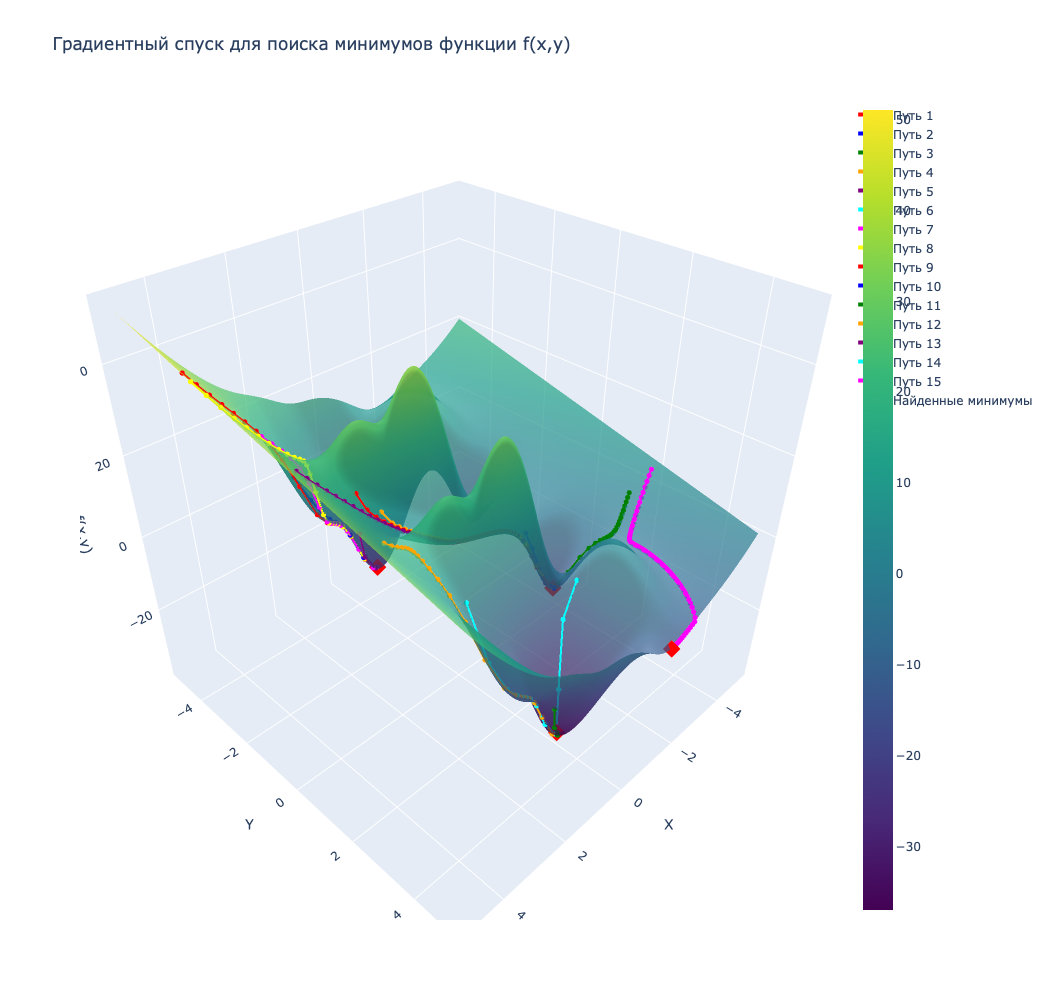


Найдено 15 потенциальных минимумов
Глобальный минимум: (-0.0576, 3.2844), значение функции: -37.0271


In [21]:
def main():
    """Основная функция для запуска всего процесса"""
    print("Запуск поиска минимумов функции с помощью градиентного спуска...")
    
    paths, minima = find_multiple_minima(num_descents=15, learning_rate=0.02)
    plot_results(paths, minima)
    
    print(f"\nНайдено {len(minima)} потенциальных минимумов")
    
    global_min = min(minima, key=lambda point: point[2])
    print(f"Глобальный минимум: ({global_min[0]:.4f}, {global_min[1]:.4f}), "
          f"значение функции: {global_min[2]:.4f}")

if __name__ == "__main__":
    main()